# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

Queremos estimar el precio de reventa de un automóvil usado a partir de sus características: año, precio de agencia actual, kilometraje, combustible, tipo de vendedor, transmisión y número de dueños previos.

Es un problema de **regresión supervisada**. La variable objetivo es `Selling_Price` y está expresada en *lakhs* de rupias indias (1 lakh = 100 000 INR).

# Caso Aplicado: Precio de Reventa de un Automóvil
## Regresión lineal y Random Forest con variables numéricas y categóricas

---

**Temas:** Variables categóricas · Pipeline · Regresión lineal · Random Forest · Validación cruzada  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento | ¿Qué forma tienen los datos y hay valores faltantes? |
| 2 — Exploración | ¿Qué variables se relacionan con el precio de venta? |
| 3 — Modelo | ¿Un Random Forest mejora a una regresión lineal con el mismo preprocesamiento? |
| 4 — Predicción | ¿Cuánto se espera que valga un auto con ciertas características? |

> Nota: este es el modelo de referencia del proyecto: todo el preprocesamiento va dentro de un Pipeline, de modo que se use exactamente igual al entrenar y al predecir.

Este notebook es un extra del modelo 02 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

El conjunto tiene 301 registros y 9 columnas:

- Car_Name      : variable cualitativa nominal, nombre del modelo (se descarta, se explica abajo)
- Year          : variable cuantitativa, año de fabricación
- Selling_Price : variable objetivo, precio de venta en lakhs
- Present_Price : variable cuantitativa, precio de agencia actual en lakhs
- Kms_Driven    : variable cuantitativa, kilometraje recorrido
- Fuel_Type     : variable cualitativa nominal (Petrol, Diesel, CNG)
- Seller_Type   : variable cualitativa nominal (Dealer, Individual)
- Transmission  : variable cualitativa nominal (Manual, Automatic)
- Owner         : variable cuantitativa, dueños anteriores

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_02_autos/` del repositorio. Son 301 filas y 9 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA)
datos.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Describir el dataset
datos.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
# Información del dataset
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [6]:
print("Cantidad de registros:", len(datos))
print("Cantidad de columnas:", len(datos.columns))
print("Filas y columnas:", datos.shape)
print("Valores nulos:", int(datos.isnull().sum().sum()))
print("Nombres de auto distintos:", datos["Car_Name"].nunique(), "en", len(datos), "filas")

Cantidad de registros: 301
Cantidad de columnas: 9
Filas y columnas: (301, 9)
Valores nulos: 0
Nombres de auto distintos: 98 en 301 filas


`Car_Name` tiene cerca de 100 valores distintos en 301 filas. Con tan pocos ejemplos por nombre no aporta capacidad de generalización, así que se descarta.

In [7]:
df = datos.copy()
df.columns = [c.lower() for c in df.columns]
df = df.drop(columns=["car_name"])
df.head()

,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

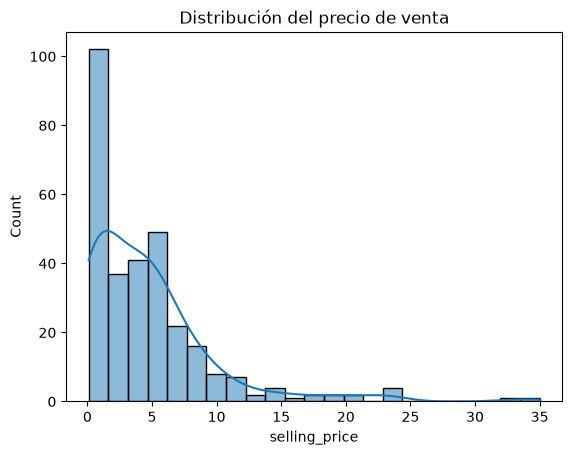

Asimetría: 2.49   Media: 4.66   Máximo: 35.00


In [8]:
OBJETIVO = "selling_price"
NUMERICAS = ["year", "present_price", "kms_driven", "owner"]
CATEGORICAS = ["fuel_type", "seller_type", "transmission"]

sns.histplot(df[OBJETIVO], kde=True)
plt.title("Distribución del precio de venta")
plt.show()
print("Asimetría: %.2f   Media: %.2f   Máximo: %.2f" % (df[OBJETIVO].skew(), df[OBJETIVO].mean(), df[OBJETIVO].max()))

La distribución tiene una asimetría positiva marcada: la mayoría de los autos cuesta poco y unos pocos llegan a precios muy altos.

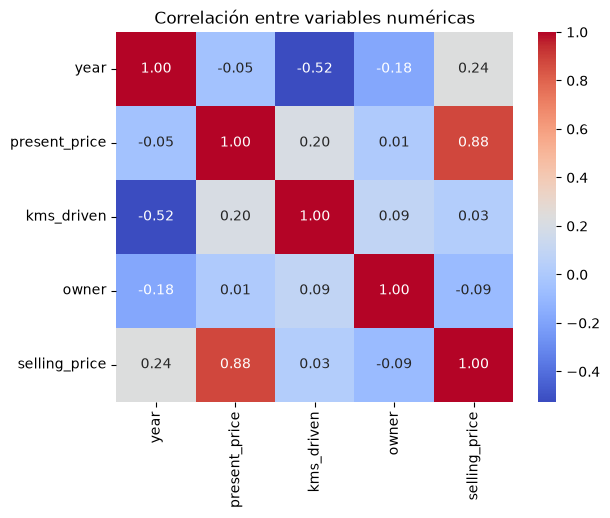

In [9]:
sns.heatmap(df[NUMERICAS + [OBJETIVO]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()

La variable con mayor correlación con el precio de venta es `present_price`, el precio de agencia actual.

> Analogía: el precio de agencia es como el precio de lista de un auto nuevo. Un auto usado vale una fracción de ese precio, y esa fracción depende de la edad, el kilometraje y el estado.

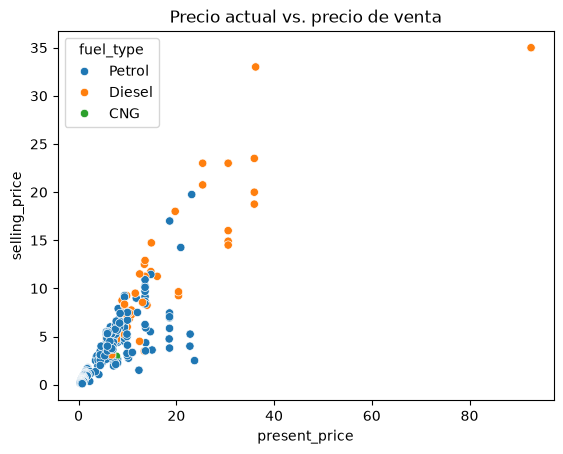

,selling_price,present_price
fuel_type,,
CNG,3.10,6.42
Diesel,10.28,15.81
Petrol,3.26,5.58


In [10]:
sns.scatterplot(data=df, x="present_price", y=OBJETIVO, hue="fuel_type")
plt.title("Precio actual vs. precio de venta")
plt.show()
df.groupby("fuel_type")[[OBJETIVO, "present_price"]].mean().round(2)

La relación es aproximadamente lineal. Los autos diésel tienen un precio de agencia y un precio de venta promedio más altos que los de gasolina.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

Se separa el 20 % de los datos para la prueba.

In [11]:
X, y = df[NUMERICAS + CATEGORICAS], df[OBJETIVO]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEMILLA)
print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)

Entrenamiento: (240, 7)  Prueba: (61, 7)


> Es importante siempre validar los rangos de los conjuntos creados, para evitar caer en extrapolación:

In [12]:
X_train[NUMERICAS].describe().loc[["min", "max"]].join(X_test[NUMERICAS].describe().loc[["min", "max"]], rsuffix="_prueba")

,year,present_price,kms_driven,owner,year_prueba,present_price_prueba,kms_driven_prueba,owner_prueba
min,2003.0,0.32,500.0,0.0,2004.0,0.51,1300.0,0.0
max,2017.0,92.60,500000.0,3.0,2018.0,35.96,135154.0,1.0


### Pipeline

El preprocesamiento (estandarizar las variables numéricas y codificar las categóricas con one-hot) va dentro del mismo objeto que el estimador. Así, lo que se aplica al entrenar es exactamente lo que se aplica al predecir un auto nuevo.

La **línea base** es una regresión lineal con el mismo preprocesamiento. El modelo principal es un **Random Forest** de 200 árboles.

In [13]:
def construir_modelo(estimador):
    preprocesador = ColumnTransformer([
        ("num", StandardScaler(), NUMERICAS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
    ])
    return Pipeline([("preprocesador", preprocesador), ("modelo", estimador)])

base = construir_modelo(LinearRegression()).fit(X_train, y_train)
modelo = construir_modelo(RandomForestRegressor(n_estimators=200, random_state=SEMILLA))

# Validación cruzada de 5 particiones, solo con el entrenamiento
cv_r2 = cross_val_score(modelo, X_train, y_train, cv=5, scoring="r2")
print("R2 en validación cruzada (Random Forest): %.3f ± %.3f" % (cv_r2.mean(), cv_r2.std()))
modelo.fit(X_train, y_train)

R2 en validación cruzada (Random Forest): 0.885 ± 0.054


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['year','present_price','kms_driven',...,'fuel_type','seller_type', 'transmission']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subse

##### Evaluación en el conjunto de prueba

In [14]:
def metricas(real, pred):
    return {"R2": r2_score(real, pred), "MAE": mean_absolute_error(real, pred), "RMSE": np.sqrt(mean_squared_error(real, pred))}

y_pred = modelo.predict(X_test)
pd.DataFrame({"Regresión lineal (línea base)": metricas(y_test, base.predict(X_test)),
              "Random Forest": metricas(y_test, y_pred)}).T.round(3)

,R2,MAE,RMSE
Regresión lineal (línea base),0.849,1.216,1.865
Random Forest,0.962,0.612,0.935


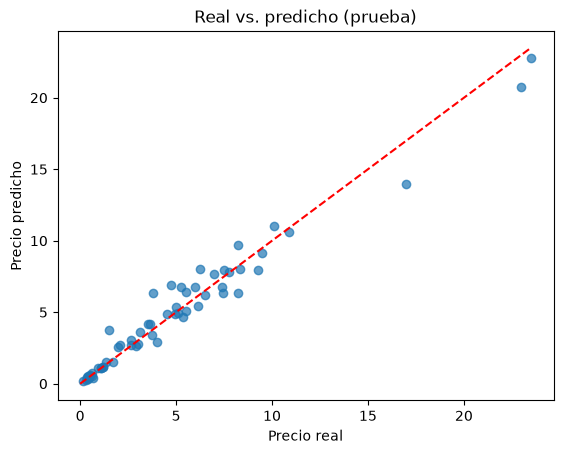

In [15]:
plt.scatter(y_test, y_pred, alpha=0.7)
limite = max(y_test.max(), y_pred.max())
plt.plot([0, limite], [0, limite], "r--")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Real vs. predicho (prueba)")
plt.show()

El Random Forest reduce el error de la línea base casi a la mitad. El R2 de prueba es mayor que el de validación cruzada: con solo 61 filas de prueba y precios muy asimétricos, la prueba es una estimación ruidosa y conviene tomar la validación cruzada como referencia más prudente.

### Predicción para un auto nuevo

In [16]:
auto = pd.DataFrame([{"year": 2016, "present_price": 8.5, "kms_driven": 30000, "owner": 0,
                      "fuel_type": "Petrol", "seller_type": "Dealer", "transmission": "Manual"}])
print("Precio de venta estimado: %.2f lakhs" % modelo.predict(auto[NUMERICAS + CATEGORICAS])[0])

Precio de venta estimado: 6.35 lakhs


---
# Conclusiones
---

## Resultados

Con las características básicas de un auto se puede estimar su precio de reventa con un error medio de aproximadamente 0.6 lakhs. El Random Forest mejora a la regresión lineal: el R2 de prueba pasa de 0.85 a 0.96.

Limitaciones: el conjunto tiene solo 301 registros y viene del mercado indio, así que no se debe usar para otros mercados. El R2 de validación cruzada (0.88) es menor que el de prueba, por el tamaño reducido de ambos conjuntos. Los precios muy altos son pocos (el máximo es 35 lakhs frente a una mediana de 3.6).